In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..', '..')))

import argparse
from pprint import pp
import torch
from torch import nn
from tqdm import tqdm
import numpy as np
import json
import os
from omegaconf import OmegaConf
from torch.utils.tensorboard import SummaryWriter

from lpn.utils import load_dataset, load_config
from lpn.utils import get_model
from lpn.utils import get_loss_hparams_and_lr, get_loss
from lpn.utils import trainer
from lpn.utils import utils
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as skimage_psnr
from skimage.metrics import structural_similarity as skimage_ssim

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
lpn_model_config_path = os.path.join('..','models','lpn','s=0.1','model_config.json')
lpn_model_weight_path = os.path.join('..','models','lpn','s=0.1','model.pt')

lpn_model_config = load_config(lpn_model_config_path)
lpn_model = get_model(lpn_model_config)
lpn_model.load_state_dict(torch.load(lpn_model_weight_path)['model_state_dict'])
lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [4]:
ne_lpn_model_config_path = os.path.join('..','models','ne_lpn','s=0.1','model_config.json')
ne_lpn_model_weight_path = os.path.join('..','models','ne_lpn','s=0.1','model.pt')
ne_lpn_model_config = load_config(ne_lpn_model_config_path)
ne_lpn_model = get_model(ne_lpn_model_config)
ne_lpn_model.load_state_dict(torch.load(ne_lpn_model_weight_path)['model_state_dict'])
ne_lpn_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [5]:
ne_lpn_by_forward_model_config_path = '../models/ne_by_forward_lpn/s=0.1/model_config.json'
ne_lpn_by_forward_model_weight_path = '../models/ne_by_forward_lpn/s=0.1/model.pt'
ne_lpn_by_forward_model_config = load_config(ne_lpn_by_forward_model_config_path)
ne_lpn_by_forward_model = get_model(ne_lpn_by_forward_model_config)
ne_lpn_by_forward_model.load_state_dict(torch.load(ne_lpn_by_forward_model_weight_path)['model_state_dict'])
ne_lpn_by_forward_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [13]:
scale_eq_lpn_by_design_config_path = os.path.join('..','models','scale_equiv_lpn','s=0.1','model_config.json')
scale_eq_lpn_by_design_weight_path = os.path.join('..','models','scale_equiv_lpn','s=0.1','model.pt')
scale_eq_lpn_by_design_config = load_config(scale_eq_lpn_by_design_config_path)
scale_eq_lpn_by_design_model =  get_model(scale_eq_lpn_by_design_config)
scale_eq_lpn_by_design_model.load_state_dict(torch.load(scale_eq_lpn_by_design_weight_path)['model_state_dict'])
scale_eq_lpn_by_design_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=False)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (3): Conv2d(3, 256

In [14]:
shift_eq_lpn_by_design_config_path = os.path.join('..','models','shift_equiv_lpn','s=0.1','model_config.json')
shift_eq_lpn_by_design_weight_path = os.path.join('..','models','shift_equiv_lpn','s=0.1','model.pt')
shift_eq_lpn_by_design_config = load_config(shift_eq_lpn_by_design_config_path)
shift_eq_lpn_by_design_model = get_model(shift_eq_lpn_by_design_config)
shift_eq_lpn_by_design_model.load_state_dict(torch.load(shift_eq_lpn_by_design_weight_path)['model_state_dict'])
shift_eq_lpn_by_design_model.to(device)

init weights


LPN(
  (lin): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (6): Conv2d(256, 64, kernel_size=(16, 16), stride=(1, 1), bias=False)
    (7): Linear(in_features=64, out_features=1, bias=True)
  )
  (res): ModuleList(
    (0): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): Conv2d(3, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 

In [6]:
dataset_config_path = os.path.join('..','configs','dataset.json')
dataset_config = load_config(dataset_config_path)
dataset_config['params']['root'] = '../../../data/bsds500'
test_dataset = load_dataset(dataset_config, 'test')
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)

dataset:  bsds500


In [7]:
scale_factors = [1,2,3,4,5]
shift_factors = [0.1,0.2,0.3,0.4,0.5]

In [8]:
def evaluate_scale_equiv(model, test_dataloader, scale_factors):
    psnr_list = []
    ssim_list = []
    for scale in tqdm(scale_factors, total=len(scale_factors)):
        psnr_sum = 0
        ssim_sum = 0
        count = 0
        for batch in test_dataloader:
            img = batch['image'].to(device)
            scaled_img = img * scale

            unscaled_output = model(img)
            scaled_output = model(scaled_img)

            unscaled_out_times_scale = unscaled_output * scale

            psnr = skimage_psnr(
                unscaled_out_times_scale.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                scaled_output.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                data_range=1.0
            )
            ssim = skimage_ssim(
                unscaled_out_times_scale.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                scaled_output.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                data_range=1.0,
                channel_axis=-1
            )
            psnr_sum += psnr
            ssim_sum += ssim
            count += 1
            
        psnr_list.append(psnr_sum / count)
        ssim_list.append(ssim_sum / count)
    return psnr_list, ssim_list

def evaluate_shift_equiv(model, test_dataloader, shift_factors):
    psnr_list = []
    ssim_list = []
    for shift in tqdm(shift_factors, total=len(shift_factors)):
        psnr_sum = 0
        ssim_sum = 0
        count = 0
        for batch in test_dataloader:
            img = batch['image'].to(device)
            shifted_img = img + shift

            unshifted_output = model(img)
            shifted_output = model(shifted_img)

            unshifted_out_plus_shift = unshifted_output + shift

            psnr = skimage_psnr(
                unshifted_out_plus_shift.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                shifted_output.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                data_range=1.0
            )
            ssim = skimage_ssim(
                unshifted_out_plus_shift.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                shifted_output.squeeze(0).permute(1, 2, 0).cpu().detach().numpy(),
                data_range=1.0,
                channel_axis=-1
            )
            psnr_sum += psnr
            ssim_sum += ssim
            count += 1
            
        psnr_list.append(psnr_sum / count)
        ssim_list.append(ssim_sum / count)
    return psnr_list, ssim_list

def evaluate_norm_equiv(model, test_dataloader, scale_factors, shift_factors):
    scale_psnrs, scale_ssims = evaluate_scale_equiv(model, test_dataloader, scale_factors)
    shift_psnrs, shift_ssims = evaluate_shift_equiv(model, test_dataloader, shift_factors)
    return scale_psnrs, scale_ssims, shift_psnrs, shift_ssims

def plot_results(scale_psnrs, scale_ssims, shift_psnrs, shift_ssims):
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    axs[0, 0].plot(scale_factors, scale_psnrs, marker='o')
    axs[0, 0].set_title('Scale Equivariance PSNR')
    axs[0, 0].set_xlabel('Scale Factor')
    axs[0, 0].set_ylabel('PSNR')

    axs[0, 1].plot(scale_factors, scale_ssims, marker='o')
    axs[0, 1].set_title('Scale Equivariance SSIM')
    axs[0, 1].set_xlabel('Scale Factor')
    axs[0, 1].set_ylabel('SSIM')

    axs[1, 0].plot(shift_factors, shift_psnrs, marker='o')
    axs[1, 0].set_title('Shift Equivariance PSNR')
    axs[1, 0].set_xlabel('Shift Factor')
    axs[1, 0].set_ylabel('PSNR')

    axs[1, 1].plot(shift_factors, shift_ssims, marker='o')
    axs[1, 1].set_title('Shift Equivariance SSIM')
    axs[1, 1].set_xlabel('Shift Factor')
    axs[1, 1].set_ylabel('SSIM')

    plt.tight_layout()
    plt.show()
    

100%|██████████| 5/5 [00:19<00:00,  3.83s/it]


LPN Scale Equivariance PSNRs:  [153.10432462093965, 17.688719526142144, 8.001534282603663, 2.75778656289285, -0.784550412211048]
LPN Scale Equivariance SSIMs:  [1.0000000008940697, 0.8589691564440727, 0.6775893975794315, 0.552233511582017, 0.46573179833590983]
LPN Shift Equivariance PSNRs:  [42.51458907478945, 37.77059991980559, 33.0395405600325, 28.526219623782666, 24.11790242641242]
LPN Shift Equivariance SSIMs:  [0.994538885653019, 0.988069885969162, 0.9778726688027382, 0.9615026360750198, 0.9333968782424926]


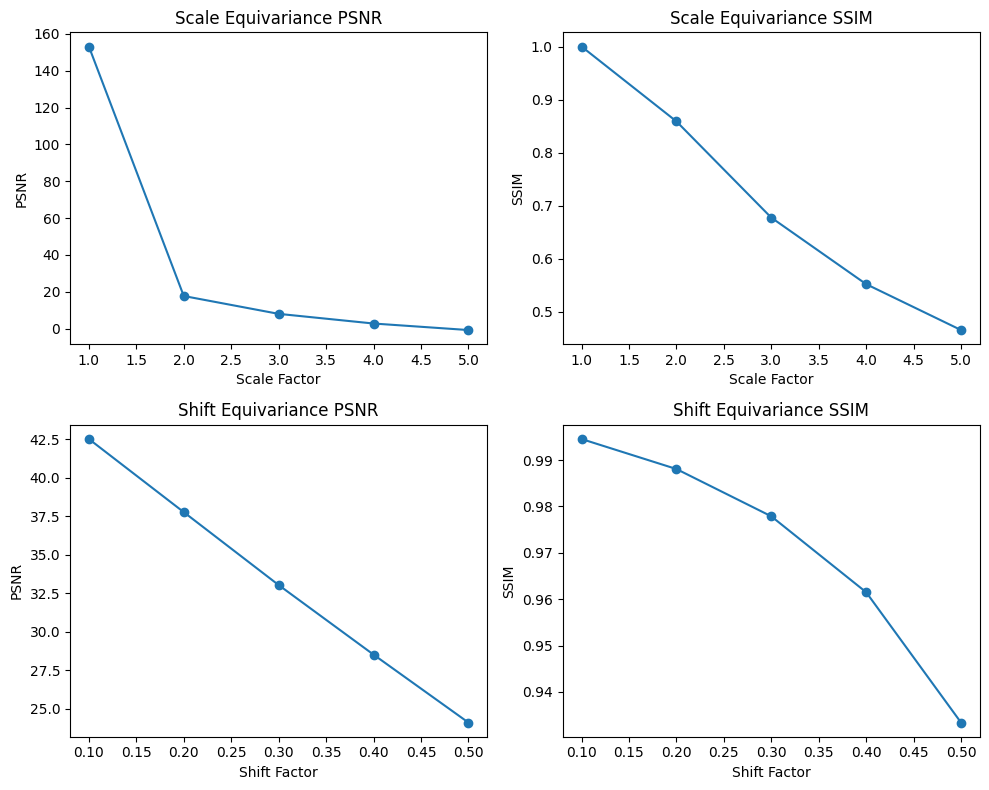

In [9]:
lpn_scale_psnrs, lpn_scale_ssims, lpn_shift_psnrs, lpn_shift_ssims = evaluate_norm_equiv(lpn_model, test_dataloader, scale_factors, shift_factors)
print("LPN Scale Equivariance PSNRs: ", lpn_scale_psnrs)
print("LPN Scale Equivariance SSIMs: ", lpn_scale_ssims)
print("LPN Shift Equivariance PSNRs: ", lpn_shift_psnrs)
print("LPN Shift Equivariance SSIMs: ", lpn_shift_ssims)
plot_results(lpn_scale_psnrs, lpn_scale_ssims, lpn_shift_psnrs, lpn_shift_ssims)

100%|██████████| 5/5 [00:22<00:00,  4.46s/it]


NE LPN Scale Equivariance PSNRs:  [150.99249495285346, 145.68006012798492, 64.45681163436622, 138.4490102551306, 59.56596596369272]
NE LPN Scale Equivariance SSIMs:  [0.9999999958276748, 0.9999999982118607, 0.999965472817421, 1.0000000062584877, 0.9999451941251755]
NE LPN Shift Equivariance PSNRs:  [108.42679599245248, 106.16644565492328, 104.45929894489575, 105.01949079037706, 103.41030995446901]
NE LPN Shift Equivariance SSIMs:  [0.9999996197223663, 0.9999997544288636, 0.9999996492266655, 0.9999997413158417, 0.9999997505545616]


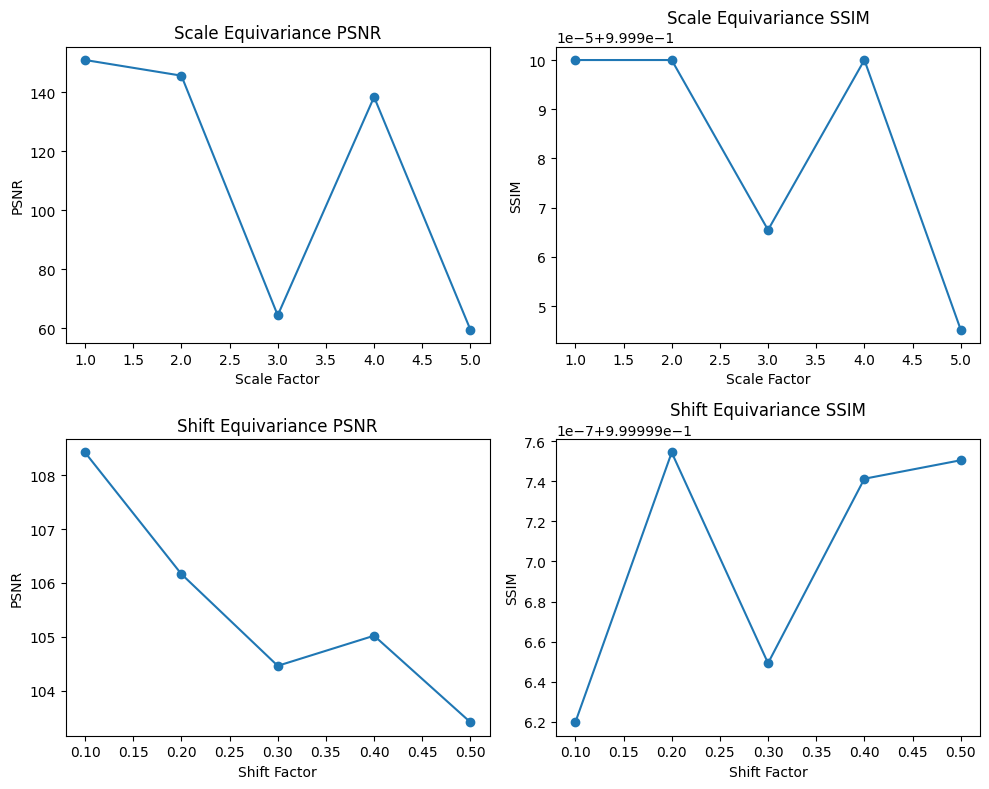

In [10]:
ne_lpn_scale_psnrs, ne_lpn_scale_ssims, ne_lpn_shift_psnrs, ne_lpn_shift_ssims = evaluate_norm_equiv(ne_lpn_model, test_dataloader, scale_factors, shift_factors)
print("NE LPN Scale Equivariance PSNRs: ", ne_lpn_scale_psnrs)
print("NE LPN Scale Equivariance SSIMs: ", ne_lpn_scale_ssims)
print("NE LPN Shift Equivariance PSNRs: ", ne_lpn_shift_psnrs)
print("NE LPN Shift Equivariance SSIMs: ", ne_lpn_shift_ssims)
plot_results(ne_lpn_scale_psnrs, ne_lpn_scale_ssims, ne_lpn_shift_psnrs, ne_lpn_shift_ssims)

100%|██████████| 5/5 [00:19<00:00,  3.87s/it]


NE by Forward LPN Scale Equivariance PSNRs:  [158.70520793809297, 152.2635833590004, 124.37065191779564, 146.27508903024744, 119.91311134015366]
NE by Forward LPN Scale Equivariance SSIMs:  [0.9999999958276748, 0.9999999856948852, 1.0000000455975533, 0.9999999669194222, 1.000000011920929]
NE by Forward LPN Shift Equivariance PSNRs:  [133.5854925552212, 132.65625909535166, 132.4420892172841, 132.30240121103304, 132.02982404029362]
NE by Forward LPN Shift Equivariance SSIMs:  [0.9999999910593033, 0.9999999976158143, 0.9999999845027924, 0.9999999910593033, 1.0000000029802323]


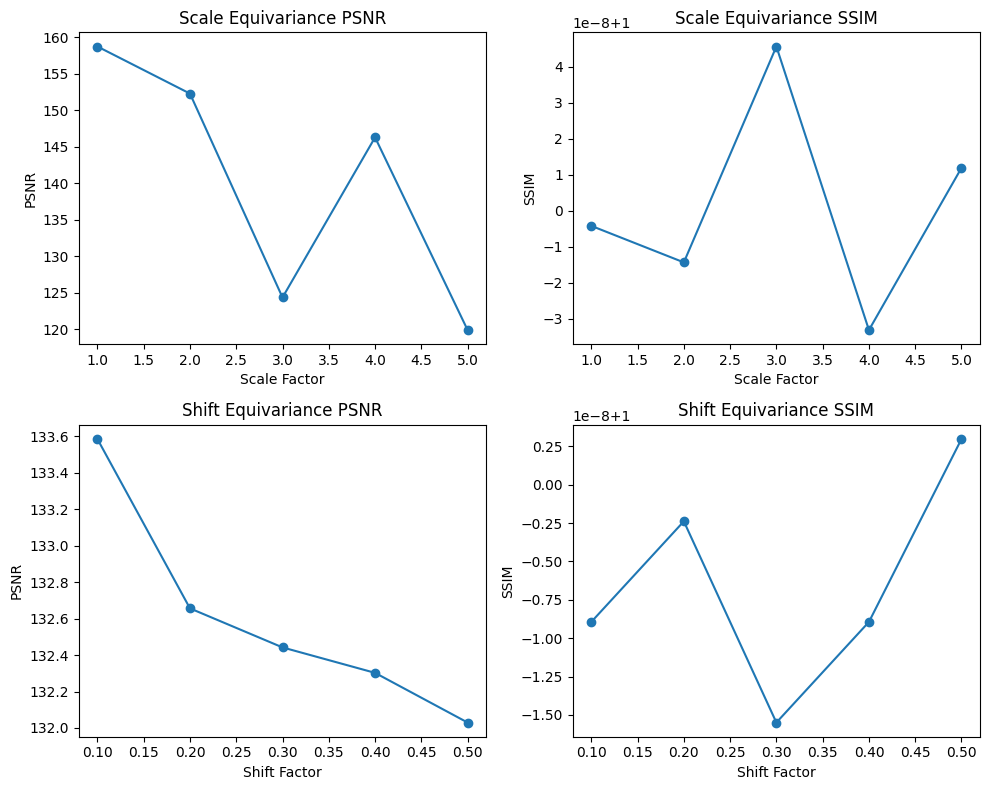

In [11]:
ne_by_forward_lpn_scale_psnrs, ne_by_forward_lpn_scale_ssims, ne_by_forward_lpn_shift_psnrs, ne_by_forward_lpn_shift_ssims = evaluate_norm_equiv(ne_lpn_by_forward_model, test_dataloader, scale_factors, shift_factors)
print("NE by Forward LPN Scale Equivariance PSNRs: ", ne_by_forward_lpn_scale_psnrs)
print("NE by Forward LPN Scale Equivariance SSIMs: ", ne_by_forward_lpn_scale_ssims)
print("NE by Forward LPN Shift Equivariance PSNRs: ", ne_by_forward_lpn_shift_psnrs)
print("NE by Forward LPN Shift Equivariance SSIMs: ", ne_by_forward_lpn_shift_ssims)
plot_results(ne_by_forward_lpn_scale_psnrs, ne_by_forward_lpn_scale_ssims, ne_by_forward_lpn_shift_psnrs, ne_by_forward_lpn_shift_ssims)

100%|██████████| 5/5 [00:22<00:00,  4.52s/it]


Scale-Equivariant by Design LPN Scale Equivariance PSNRs:  [148.57765737172514, 143.2688936337572, 64.43823067806073, 136.61766256548432, 58.6982714247325]
Scale-Equivariant by Design LPN Scale Equivariance SSIMs:  [0.9999999982118607, 1.0000000026822091, 0.9998642134666443, 0.9999999874830245, 0.9998486176133156]
Scale-Equivariant by Design LPN Shift Equivariance PSNRs:  [27.39648386348183, 24.21597456174923, 22.381432215904965, 21.06829021631441, 20.040828892968044]
Scale-Equivariant by Design LPN Shift Equivariance SSIMs:  [0.8595216554403305, 0.7777451476454735, 0.7178955549001693, 0.6703251565992833, 0.6317768923938274]


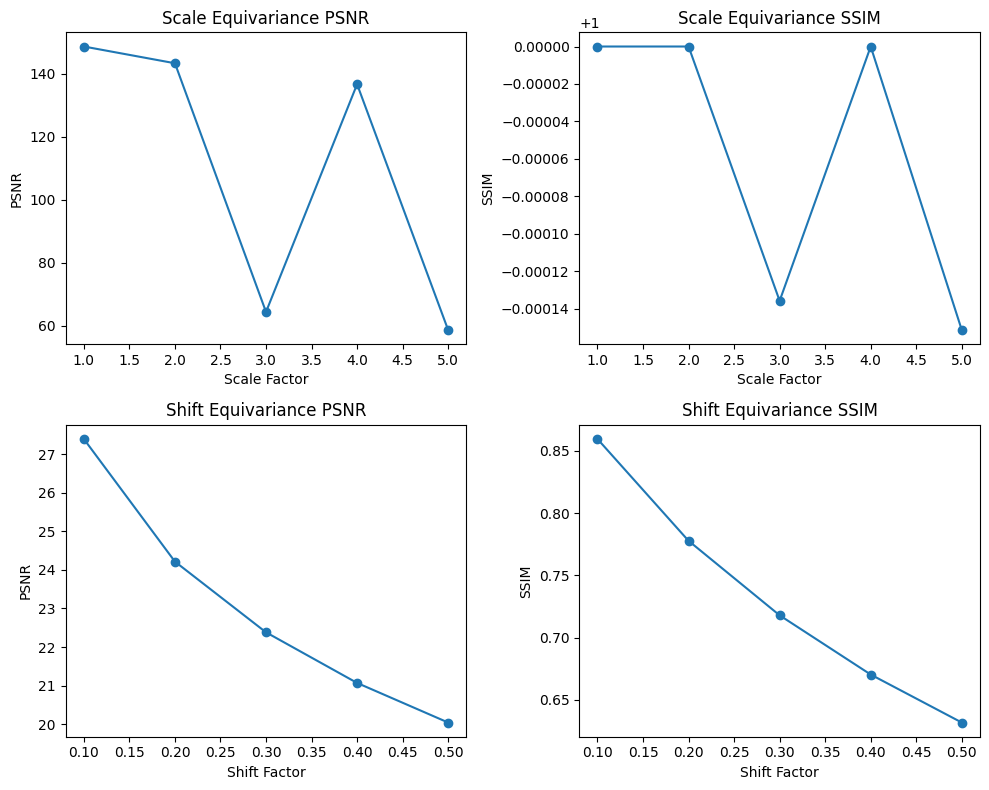

In [15]:
scale_eq_by_design_psnrs, scale_eq_by_design_ssims, shift_eq_by_design_psnrs, shift_eq_by_design_ssims = evaluate_norm_equiv(scale_eq_lpn_by_design_model, test_dataloader, scale_factors, shift_factors)
print("Scale-Equivariant by Design LPN Scale Equivariance PSNRs: ", scale_eq_by_design_psnrs)
print("Scale-Equivariant by Design LPN Scale Equivariance SSIMs: ", scale_eq_by_design_ssims)
print("Scale-Equivariant by Design LPN Shift Equivariance PSNRs: ", shift_eq_by_design_psnrs)
print("Scale-Equivariant by Design LPN Shift Equivariance SSIMs: ", shift_eq_by_design_ssims)
plot_results(scale_eq_by_design_psnrs, scale_eq_by_design_ssims, shift_eq_by_design_psnrs, shift_eq_by_design_ssims)

100%|██████████| 5/5 [00:21<00:00,  4.22s/it]


Shift-Equivariant by Design LPN Scale Equivariance PSNRs:  [152.5372441051938, 26.38621483639768, 18.677028682866823, 13.975153788076916, 10.731278928912065]
Shift-Equivariant by Design LPN Scale Equivariance SSIMs:  [1.0000000044703483, 0.902789520919323, 0.7915682108700275, 0.7107791313529015, 0.653008174598217]
Shift-Equivariant by Design LPN Shift Equivariance PSNRs (self-denoised):  [131.84198379920528, 130.2690322814966, 130.49206978815008, 130.48415648146982, 129.99171960430326]
Shift-Equivariant by Design LPN Shift Equivariance SSIMs (self-denoised):  [1.000000001490116, 0.999999991953373, 0.9999999928474427, 0.9999999719858169, 1.0000000140070915]


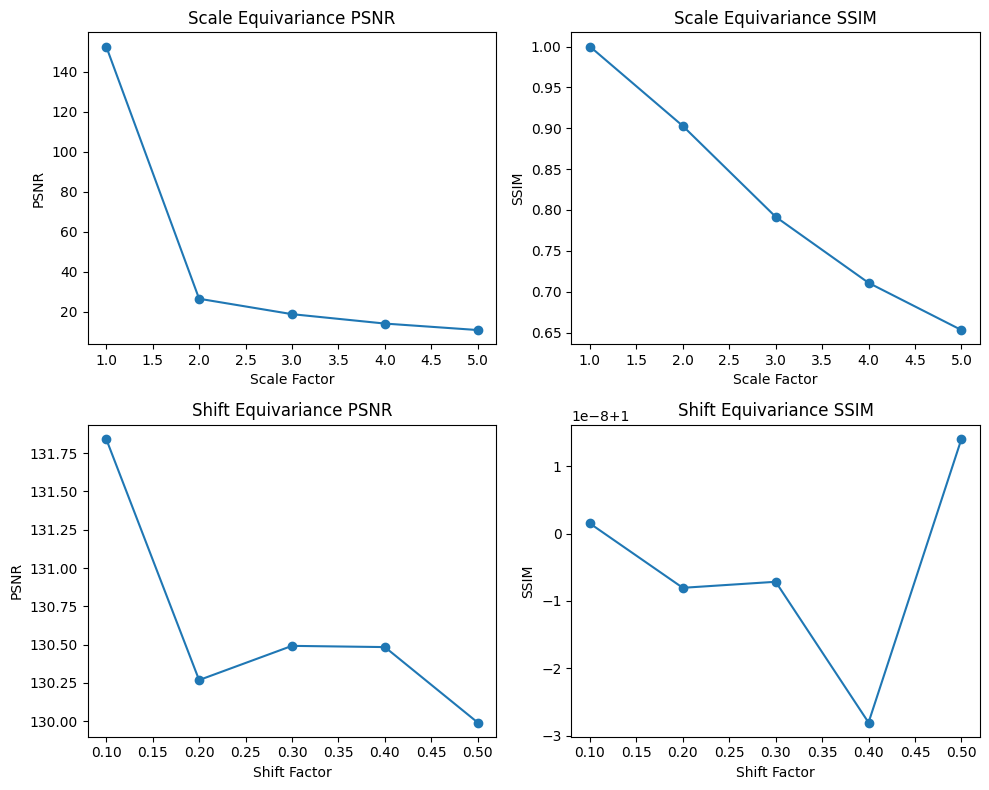

In [20]:
shift_eq_by_design_scale_psnrs, shift_eq_by_design_scale_ssims, shift_eq_by_design_shift_psnrs, shift_eq_by_design_shift_ssims = evaluate_norm_equiv(shift_eq_lpn_by_design_model, test_dataloader, scale_factors, shift_factors)
print("Shift-Equivariant by Design LPN Scale Equivariance PSNRs: ", shift_eq_by_design_scale_psnrs)
print("Shift-Equivariant by Design LPN Scale Equivariance SSIMs: ", shift_eq_by_design_scale_ssims)
print("Shift-Equivariant by Design LPN Shift Equivariance PSNRs (self-denoised): ", shift_eq_by_design_shift_psnrs)
print("Shift-Equivariant by Design LPN Shift Equivariance SSIMs (self-denoised): ", shift_eq_by_design_shift_ssims)
plot_results(shift_eq_by_design_scale_psnrs, shift_eq_by_design_scale_ssims, shift_eq_by_design_shift_psnrs, shift_eq_by_design_shift_ssims)